**Tasks:** 

1. Determine the best-selling product sub-category.

2. Identify the product category generating the highest revenue.

4. Compile a top 10 list of the most valuable customers.

5. Determine the state responsible for the highest number of orders.

6. Find the year with the highest revenue generation.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib as plt
import os
import time
import sys
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

print("Libs Imported")

Libs Imported


In [2]:
# Force Spark to use the exact same Python executable as your notebook/script
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
# Run this before creating your SparkSession,
# if you are using Spark on Java 21 as it sometimes causes issues with Spark's networking.
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

In [3]:
spark = SparkSession.builder\
    .appName("Superstore_Analysis")\
    .master('local[*]')\
    .getOrCreate()

print('Session Created')

Session Created


# Data Cleaning

In [4]:
file_path = 'superstore_data.csv' 

superstore_data = pd.read_csv(file_path, encoding_errors = 'ignore')

superstore_data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
superstore_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
col_names = superstore_data.columns.to_list()
final_col_names = []

for names in col_names:
    names = names.replace(' ', '_').lower()
    final_col_names.append(names)
    #print(names) 

superstore_data.columns = final_col_names
print(superstore_data.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')


In [7]:
superstore_data['order_date'] = pd.to_datetime(superstore_data['order_date'], format = '%m/%d/%Y')
superstore_data['ship_date'] = pd.to_datetime(superstore_data['ship_date'], format = '%m/%d/%Y')

superstore_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub-category   9994 non-null   s

# Analysis

In [8]:
data = spark.createDataFrame(superstore_data)

data.show()

+------+--------------+-------------------+-------------------+--------------+-----------+------------------+-----------+-------------+---------------+--------------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|row_id|      order_id|         order_date|          ship_date|     ship_mode|customer_id|     customer_name|    segment|      country|           city|         state|postal_code| region|     product_id|       category|sub-category|        product_name|   sales|quantity|discount|  profit|
+------+--------------+-------------------+-------------------+--------------+-----------+------------------+-----------+-------------+---------------+--------------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156|2016-11-08 00:00:00|2016-11-11 00:00:00|  Second Class|   CG-12520|       Claire Gute|   Consumer|United State

In [15]:
#Determine the best-selling product sub-category.

best_selling_sub_category = data.groupBy('sub-category')\
                                .count()\
                                .orderBy('count', ascending = False).limit(10)

best_selling_sub_category.show()

+------------+-----+
|sub-category|count|
+------------+-----+
|     Binders| 1523|
|       Paper| 1370|
| Furnishings|  957|
|      Phones|  889|
|     Storage|  846|
|         Art|  796|
| Accessories|  775|
|      Chairs|  617|
|  Appliances|  466|
|      Labels|  364|
+------------+-----+



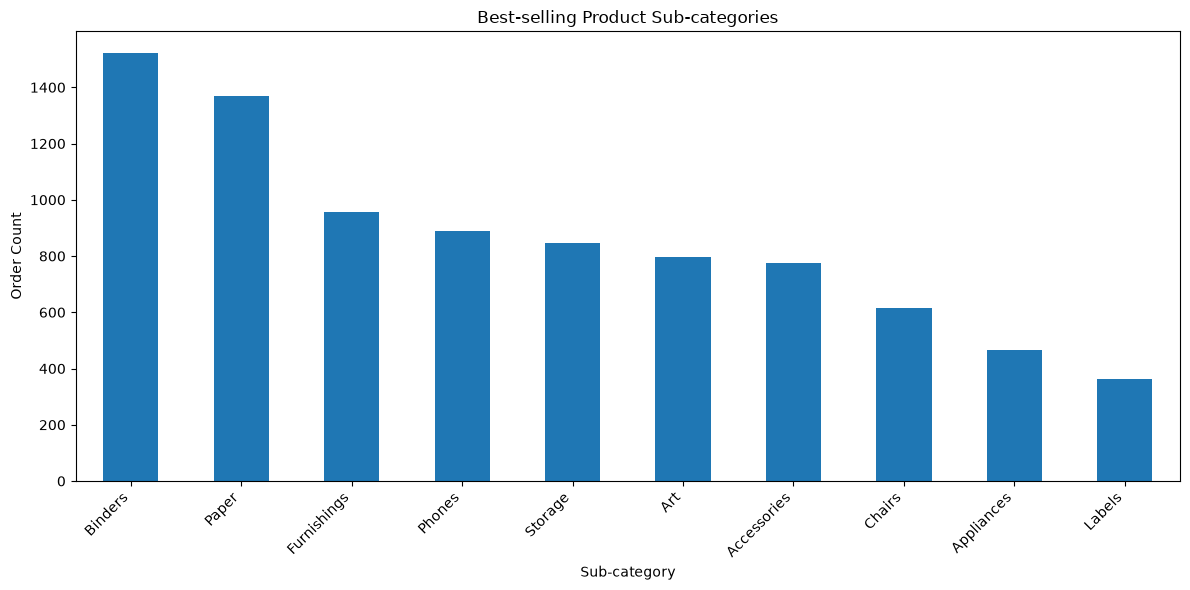

In [16]:
best_selling_sub_category_pd = best_selling_sub_category.toPandas()

ax = best_selling_sub_category_pd.plot(
    kind='bar',
    x='sub-category',
    y='count',
    legend=False,
    figsize=(12, 6),
    title='Best-selling Product Sub-categories'
)

plt.pyplot.xlabel('Sub-category')
plt.pyplot.ylabel('Order Count')
plt.pyplot.xticks(rotation=45, ha='right')
plt.pyplot.tight_layout()
plt.pyplot.show()

In [10]:
categories = data.select('category').distinct()

categories.show()

+---------------+
|       category|
+---------------+
|Office Supplies|
|      Furniture|
|     Technology|
+---------------+



In [11]:
# Category with highest revenue

highest_revenue = data.groupBy('category')\
                        .agg(
                            F.round(
                                    F.sum(
                                            F.col('sales') * F.col('quantity') * (1 - F.col('discount'))
                                    ), 3
                            ).alias('total_revenue')
                        ).orderBy(F.col('total_revenue').desc())
                    
highest_revenue.show()


+---------------+-------------+
|       category|total_revenue|
+---------------+-------------+
|     Technology|  3491750.008|
|      Furniture|   3229364.56|
|Office Supplies|   3173069.37|
+---------------+-------------+



In [12]:
# Find top 10 valuable customers 

top_10_customers = data.groupBy('customer_name')\
                        .agg(F.round
                             (F.sum
                              (F.col('sales') * F.col('quantity') * (1-F.col('discount'))
                              ), 3 
                                ).alias('total_revenue')
                                ).orderBy(F.col('total_revenue').desc()).limit(10)
top_10_customers.show()

+-------------+-------------+
|customer_name|total_revenue|
+-------------+-------------+
|Adrian Barton|   141627.401|
| Tamara Chand|    92482.748|
|  Sean Miller|    76095.838|
| Bill Shonely|    70965.359|
| Ken Lonsdale|    69261.154|
|Daniel Raglin|     63842.28|
|Maria Etezadi|     62866.97|
|    Greg Tran|    61821.845|
| Sanjit Chand|    61481.979|
| Raymond Buch|    60880.521|
+-------------+-------------+



In [13]:
# Determine the state with the highest number of orders

states_with_high_orders = data.groupBy('state').count().withColumnRenamed('count','no_of_orders')\
                                               .orderBy('no_of_orders', ascending = False).limit(10)

states_with_high_orders.show()

+--------------+------------+
|         state|no_of_orders|
+--------------+------------+
|    California|        2001|
|      New York|        1128|
|         Texas|         985|
|  Pennsylvania|         587|
|    Washington|         506|
|      Illinois|         492|
|          Ohio|         469|
|       Florida|         383|
|      Michigan|         255|
|North Carolina|         249|
+--------------+------------+



In [14]:
# Year with hightest revenue

year_with_highest_revenue = data.groupBy(F.year('order_date').alias('year'))\
                                .agg(F.round
                                         (F.sum
                                                (F.col('sales') * F.col('quantity') * (1 - F.col('discount'))
                                         ), 3 ).alias('total_revenue')
                                    ).orderBy(F.col('total_revenue').desc()).limit(10)

year_with_highest_revenue.show()

+----+-------------+
|year|total_revenue|
+----+-------------+
|2017|  3088478.552|
|2016|  2679682.328|
|2014|  2067591.866|
|2015|  2058431.192|
+----+-------------+



# End

In [ ]:
#spark.stop()